<a href="https://colab.research.google.com/github/nishant26baisoya-code/Data-science_gen_-ai_project/blob/main/Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dimensionality Reduction**

In [15]:
#Another variant of Un-supervised learning

#Dimensionailty reduction is a technique to reduce the number of input features(variables)
#in a dataset while preserving the most important information(variance)

#Why Dimensioality Reduction
  # -1)curse of dimensionality :if more features--->complex to model
  # -2)overfitting   : model learns noise instead of patterns
  # -3)High computation cost
  # -4)Difficulty in visualization

#if 10-15 i/p features--->it is good
#some times--->we see 100's of i/p features
#ex: images
#ex: an image size---->28x28=784 pixels
#    means here 784 i/p's

#when more i/p features---->we see overfit
#The algorithm wont understand the patterns properly and it cannot make
#proper correlation-->so we call this as curse of dimensionality

#If there are too many i/p features, then it is not good to predict the target
#To overcome this,we need to start reducing the features
#while reducing the features--->we avoid overfitting
#model starts functioning well.

#while reducing features--->we may tend to loose some knowledge
#but while reducing the features, how much knowledge it looses
#ex: 500features---->reduce them to 10 features
#    and am able to say that-->90% of original variance(knowledge) i covered
#    some 10% of knowledge is lost
#    but if you use this 500features-->then the entire model will fail
#so to avoid this---->we use any one of the dimensioanlity  reduction technique
#that will help you to reduce the features and that too nearly 90% of vaiance is
#covered

#Here we have
#Feature selection->if 12 features->selecting 5 features  from it, we say Feature selection


#Feature extraction--->from 500 features bringing consolidated 10 features with
#                      90% of variance

#Here we have 3 popular Techniques:
# 1)PCA (Principal Component Analysis) ---->works well for linear datasets
# 2)t-SNE (t-Distributed Stochastic Neighbor Embedding)--->For non-Linear datasets
# 3)UMAP (Uniform Manifold Approximation and Projection)--> "   "     "        "


**PCA Technique**

In [16]:
#PCA --->Principal Component Analysis

#It is most widely used

#Converts data into new variables called principal components

#These components capture maximum variance(nearly 90%)

#ex: 10features--->PCA can reduce them to 2 or 3 features
#                 while keeping most of the information

#what PCA Does
  #  -1)Reduce the number of features(i/p variables)
  #  -2)keep maximum important information(variance)
  #  -3)Remove noise and redundancy
  #  -4)simplify data
  #  -5)improves model performance(as features as reduced)


#ex: You got list of datapoints plotted on a multi-dimensional space

#whenever we call PCA--->It takes mean as 0 and Standard Deviation as 1 i.e Z-score

#How PCA works?

#Step-1 :Standardize the Data
#        -initially PCA will standardize the Data i.e with as 0 as mean and 1 as SD

#Step-2:Compute Co-variance matrix
      #  -It checks how all the features are varying together
      #  -It shows how variables relate to each Other
      #  -If 2 variables change together then--->high covariance
      #  -for that it calculates the co-variance matrix
      #  -Once matrix is created

#Step-3:Compute Eigen vectors and Eigen values
      #  -It prepares--->1)Eigen vectors(directions of new axes)
      #                                   (here directions=principal components)
      #                  2)Eigen values(variance) -Importance of each direction
      #It identifies the direction of maximum variance

      #check the diagram

      #Co-variance matrix means---->how multiple features are varying together,

      #Co-variance means feature1,feature2,how they are varying

      #From co-variance matrix, it calculates the eigen vector and eigen values
      #nothing but it identifies multiple principal component

      #pc1-->The 1st principal component will be the direction of highest variance

      #Everything will be orthogonal to each other

      #pc2--->direction of 2nd highest variance, that is orthogonal to pc1

      #Next it calculates the 3rd Eigen vector

      #pc3--->direction of 3rd highest variance,which is orthogonal to pc1 and pc2
      #Likewise it keeps on calculating diff eigen vectors-->pc4,pc5....

      #pc1,pc2,pc3 are the reduced features

      #ex: If you have passed 500 features then we see

      #pc1----->will cover 60% of maximum variance
      #pc2-----> "     "   20% of   "        "
      #pc3----->"      "   5%  of   "        "
      #pc4----->"      "   2%  of   "        "
      #         sum these-->87% ov variance covered

      #if 80% to 90% of variance is covered--->we say it is good

      #Advantages:
      #      -Reduces complexity
      #      -Removes multi-collinearity


      #Disadvantages:
      #      -Hard to interpret the new features
      #      -some information lost


      #This PCA technique is used when the data is linear

      #If the dataset is linear--->Then PCA will work more efficiently

      #But if ur dataset is having lot of non-linearity--->how to handle this
      #-we go for other 2 techniques---->t-SNE and UMAP , which handles non-Linear


In [17]:
#Step 1: import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
#step 2: Loading data and creating a df
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [19]:
#Banking domain data---->V1,V2,V3......V28
#They dont want o share the feature names

In [20]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134763 entries, 0 to 134762
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    134763 non-null  int64  
 1   V1      134763 non-null  float64
 2   V2      134763 non-null  float64
 3   V3      134763 non-null  float64
 4   V4      134763 non-null  float64
 5   V5      134763 non-null  float64
 6   V6      134763 non-null  float64
 7   V7      134763 non-null  float64
 8   V8      134763 non-null  float64
 9   V9      134763 non-null  float64
 10  V10     134763 non-null  float64
 11  V11     134763 non-null  float64
 12  V12     134763 non-null  float64
 13  V13     134763 non-null  float64
 14  V14     134763 non-null  float64
 15  V15     134763 non-null  float64
 16  V16     134763 non-null  float64
 17  V17     134763 non-null  float64
 18  V18     134763 non-null  float64
 19  V19     134763 non-null  float64
 20  V20     134763 non-null  float64
 21  V21     13

In [22]:
df.shape   #we have 31 columns

(134763, 31)

In [23]:
#V1, V2, V3.....-> It is very difficult to interpret

#step: 3:pre-processing----> dropping un-wanted Columns like Time

df.drop("Time",axis=1,inplace=True) #Modifying within the same df
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [24]:
#step 4:standardize------> by applying scaling
#in the above output--->all cols are in scaled form b/w -3 to +3 except Amount column

#So we apply standard scaler
from sklearn.preprocessing import StandardScaler
#i.initialize
scaler = StandardScaler()

#ii.apply fit_transform
df['Amount']=scaler.fit_transform(df[['Amount']])
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.231480,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.357907,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.150237,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.126703,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.087943,0.0


In [25]:
#Amount column also got scaled

In [26]:
#Step 5: creating input dataframe by removing the o/p variable
#Here the last col--->class is the o/p variable, so remove it to create a input dataframe(X)

X= df.drop('Class', axis=1)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.231480
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.357907
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.150237
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.126703
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.087943


In [27]:
#Now X Contains only i/p variables---->V1 to V28 and Amount column

#This X, am going to use it for my PCA
#From X--->i will be building principal component

In [34]:
#Step 6 :Applying PCA
#from sklearn.decomposition import PCA
#       for PCA,we provide one hyperparameter--->n_components
#       here randomly, i will provide n_components=15
#       means from total 31 features -2(Time,class)=29 i/p features
#       from this 29 i/p features---->we get 15 (as we provided n_components=15)

# Handle NaN values before applying PCA
X = X.dropna()

# i)initializing PCA
pca=PCA(n_components=15) #we get 15 features

# ii)apply fit_transform
X_principal_components=pca.fit_transform(X)
X_principal_components

array([[-0.70824392, -0.11617138,  0.87464542, ..., -1.05880224,
         0.65007619, -0.81120294],
       [ 1.34226754,  0.1266461 , -0.45183005, ...,  0.31298147,
        -0.73340343,  0.23830742],
       [-1.38177003, -1.59792569, -0.00821836, ...,  0.61869117,
        -0.10824447, -4.39615015],
       ...,
       [ 1.20752946, -0.43214382, -0.33730168, ...,  0.84472064,
        -1.45015376, -0.5164954 ],
       [-0.2114865 ,  1.23437837,  0.59442974, ..., -0.89494085,
         0.54907552, -0.46866375],
       [ 1.30258401, -0.27637018, -0.36762815, ...,  0.01887244,
        -0.93402312,  0.53843794]])

In [35]:
#Now you got 15 components
#how do i know from this 15, how much % of variance(knowledge) is covered
#To explain variance ratio--->for that--->we have a command
res=pca.explained_variance_ratio_
res

array([0.12401265, 0.10326769, 0.07380006, 0.06154152, 0.0603256 ,
       0.0588718 , 0.04978201, 0.04911531, 0.03894072, 0.03728398,
       0.03620358, 0.03558036, 0.03379205, 0.03239064, 0.02612658])

In [36]:
#here PC1--->0.124---->highest variance
#        --->it covers 12.4% of variance
#     PC2--->0.099--->means 9.9% of variance--->2nd highest variance
#     PC3--->0.073--->means 7.3% of variance--->3rd highest variance
#     PC4--->0.065--->means 6.5% of variance--->4th highest variance
#     keeps on reducing....

#sum up all these 15percentages
#check whether you can reach 80-90% of variances are covered
#If it is covered then X_principal_components will be considered as reduced i/p features
#so that X_pricipal_components can be used as i/p to other algorithms
#insead of using 29components--->we can use 15components as i/p to other algorithms

tot_variance_percent=np.sum(res)
print(tot_variance_percent)


0.8210345478196446


In [37]:
#If you still want to increase variance--->
#Explore and increase the hyper parameter(n_components from 15 to 20)

# i)initializing PCA
pca=PCA(n_components=20) #we get 15 features

# ii)apply fit_transform
X_principal_components=pca.fit_transform(X)

res=pca.explained_variance_ratio_
res

array([0.12401265, 0.10326769, 0.07380006, 0.06154152, 0.0603256 ,
       0.0588718 , 0.04978201, 0.04911531, 0.03894072, 0.03728398,
       0.03620358, 0.03558036, 0.03379205, 0.03239064, 0.02612658,
       0.02452709, 0.02259061, 0.0209778 , 0.0192541 , 0.01854484])

In [38]:
tot_variance_percent=np.sum(res)
print(tot_variance_percent)

0.9269289747750902


In [39]:
#ex:2

In [40]:
#Step 1: import libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

#Step 2: Sample data
df=pd.DataFrame({'X':[2,4,6,8],'Y':[1,3,5,7]})
print(df)

#Step 3: Standardize---->scaling
#i)initialize
scaler=StandardScaler()

#ii)apply fit_transform
scaled_data=scaler.fit_transform(df)
scaled_data

   X  Y
0  2  1
1  4  3
2  6  5
3  8  7


array([[-1.34164079, -1.34164079],
       [-0.4472136 , -0.4472136 ],
       [ 0.4472136 ,  0.4472136 ],
       [ 1.34164079,  1.34164079]])

In [41]:
#step 4: Apply PCA
#i)intializing
pca=PCA(n_components=1) #in datasets,2 cols available, i want to reduce to 1

#ii)fit_transform
principal_components=pca.fit_transform(scaled_data)
print(principal_components)

[[-1.8973666 ]
 [-0.63245553]
 [ 0.63245553]
 [ 1.8973666 ]]


In [43]:
#we got only 1 column(reduced dimension)

In [44]:
#step 5: Explain variance ratio
res=pca.explained_variance_ratio_
res=pca.explained_variance_ratio_
res

array([1.])

In [45]:
#ex:3

In [46]:
# Principal Component Analyis(PCA) is a dimensionality reduction technique,
# It transforms high-dimensianal data into smaller number of dimensions
# called principal components and keeps important information in the data

In [48]:
#step 1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score,roc_auc_score

#Step 2:Load the data and create a df
df = pd.read_csv("cancer_data.csv")
df.head()



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [49]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [51]:
df.shape

(569, 33)

In [52]:
#Step 3: Data Cleaning and pre-processing

#i)Removing the un-wanted columns
#dropping the columns like  id and Unnamed:32
df.drop(['id', 'Unnamed: 32'],axis=1,inplace=True) #from the same df
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [53]:
#ii)Label encoding for the column--->'diagnosis'
#This diagnosis ,we will take it as a output column
#It has 2 value (2 o/p classes)----> 'M' and 'B
#'M' --->maligent
#'B'---->benign
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [54]:
#now performing Label encoding for these--->'M' to 1 and 'B' to 0

df['diagnosis'] = df['diagnosis'].map({'M': 1,'B' :0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [55]:
#Step 4: Seperating Features and Target and creating input (X) and Output(Y) df
X=df.drop('diagnosis',axis=1)
Y=df['diagnosis']

In [56]:
#Step 5: Standardize the Data- Scaling
#        as the columns have diff values
#StandardScaler transforms the features so that they all have mean=0 and
#standard deviation=1 which helps PCA to treat all features equally

#i)initializing
scaler=StandardScaler()

#ii)apply fit_transform
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [57]:
#Before training the model, as the  dataset has 30 i/p columns , i want to
#apply dimensioality reduction technique(PCA) to reduce the i/p columns

#step 6: Apply PCA Algorithm
#here we get reduced principal components--->PC1,PC2,PC3,......
#PCA finds combinations of original features

#i)initializing
pca=PCA(n_components=15)

#ii)apply fit_transform
X_principal_components=pca.fit_transform(X_scaled)
X_principal_components

array([[ 9.19283683e+00,  1.94858307e+00, -1.12316616e+00, ...,
        -1.03387665e-01, -6.90804097e-01,  6.01793127e-01],
       [ 2.38780180e+00, -3.76817174e+00, -5.29292687e-01, ...,
         9.43529283e-01, -6.53475327e-01, -8.97486713e-03],
       [ 5.73389628e+00, -1.07517380e+00, -5.51747593e-01, ...,
         4.10626602e-01,  1.66797587e-02, -4.83419744e-01],
       ...,
       [ 1.25617928e+00, -1.90229671e+00,  5.62730526e-01, ...,
        -1.57417952e-01,  2.85690875e-01, -9.09977705e-02],
       [ 1.03747941e+01,  1.67201011e+00, -1.87702933e+00, ...,
        -1.22519497e+00,  2.18697665e-01, -2.29591034e-01],
       [-5.47524330e+00, -6.70636791e-01,  1.49044308e+00, ...,
        -6.78897480e-01, -1.17072466e+00, -2.17343343e-01]])

In [58]:
#we reduced 30 features to 15 components
#Each row now has 15 values(PC1,PC2,PC3......) instead of 30
#These 15 components contains the most variation from the original data
#PC1 has the 1st highest varaince
#PC2 has the 2nd    "       "

#Step 7: Explain Variance ratio
#It tells how much information(variance) each principal component holds

res=pca.explained_variance_ratio_
res

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978,
       0.00979719, 0.00870538, 0.00804525, 0.00523366, 0.00313783])

In [59]:
#PC1-44.2%
#PC2-18.9%
#PC3-9.3%
#PC4-6.6%

#Now sum all the 15components percentages--->it should have 80% variance(knowlwdge)
# else exploring / increasing the hyper parameter(n_components to 20)

#Now calculating the sum
tot_variance_percent=np.sum(res)
print(tot_variance_percent)

0.9864881227145469


In [60]:
#so total 98% of variance(information)

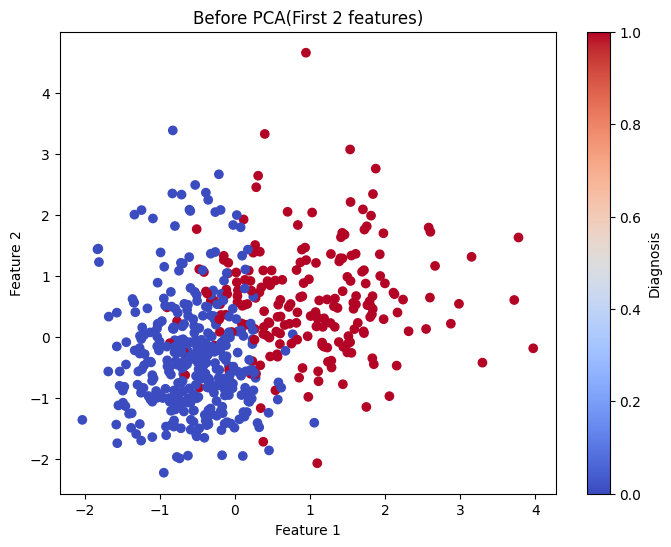

In [61]:
#Step 8: Visualizing Before and after PCA

#1st plot--->shows before PCA --->we take 1st 2 features of scaled data
#2nd plot--->shows after PCA----->we take 1st 2 PCA components
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=Y,cmap='coolwarm') #here Y-->o/p variable
plt.xlabel('Feature 1')                          #no of colors= no of o/p variable values
plt.ylabel('Feature 2')
plt.title('Before PCA(First 2 features)')
plt.colorbar(label="Diagnosis")
plt.show()


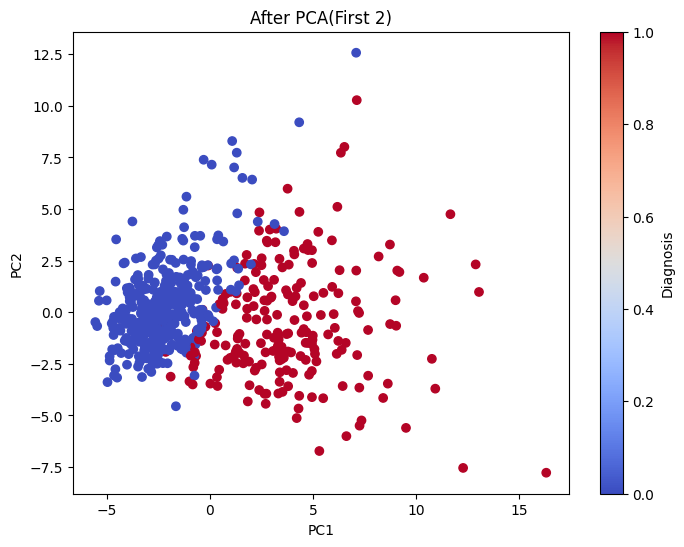

In [62]:
plt.figure(figsize=(8,6))
plt.scatter(X_principal_components[:,0],X_principal_components[:,1],c=Y,cmap='coolwarm')
plt.xlabel('PC1')                          #no of colors= no of o/p variable values
plt.ylabel('PC2')
plt.title('After PCA(First 2)')
plt.colorbar(label="Diagnosis")
plt.show()

In [63]:
#Step 9:Train the model using the PCA DAta
#i)spltting into train and test
X_train,X_test,Y_train,Y_test=train_test_split(X_principal_components,Y,test_size=0.2,random_state=42)
#here i/p--->X_principal_components
#     o/p--->Y -->target variable

In [64]:
#step 10 : apply the model

#i)initialize the model
model=LogisticRegression()

#ii)train the model
model.fit(X_train,Y_train)

#iii)predicting
Y_pred=model.predict(X_test)

In [65]:
print("Classification Report for Logistic Regression Model:")
print("y_actual:",Y_test.values)
print("y_pred  :",Y_pred)

print(classification_report(Y_test,Y_pred))

print("Accuracy Score:",accuracy_score(Y_test,Y_pred))

print("Precision Score(1):",precision_score(Y_test,Y_pred))
print("Precision Score(0):",precision_score(Y_test,Y_pred,pos_label=0))

print("Recall Score(1):",recall_score(Y_test,Y_pred))
print("Recall Score(0):",recall_score(Y_test,Y_pred,pos_label=0))

print("F1 Score(1):",f1_score(Y_test,Y_pred))
print("F1 Score(0):",f1_score(Y_test,Y_pred,pos_label=0))

print("ROC-AUC Score:",roc_auc_score(Y_test,model.predict_proba(X_test)[:,1]))

Classification Report for Logistic Regression Model:
y_actual: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]
y_pred  : [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

Accuracy Score: 0.9912280701754386
Precision Score(1): 1.0
Precision Score(0): 0.9861111111111112
Recall Score(1): 0.9767441860465116


**t-SNE**

In [66]:
#t-SNE-->(t-Distributed Stochastic Neighbor Embedding)

#t-SNE is specifically designed for non-linearity dimensionality reduction

#For non-linearity, mostly for images
#ex:

# |
# |     O
# |    /|\                                |__|-object
# |     |                                      here distance b/w the objects is more
# |    / \ Person
# |___________________________________________________________________________

#The above image is non-linear
#The above image after reducing dimensions is as shown below
# |
# |     O
# |    /|\            |_|-object    here distance b/w the objects is less
# |    / \ Person
# |___________________________________________________________________________

#If you apply t-SNE, it is capable of taking care of local neighborhood
#i.e preserving local structure

#means after you redue the dimensions,you will still see the same preservation of
#the person,but the sistance b/w the objects are not preserved

#In the above image, there are 2 objects
#local structures means---->these 2 objects are preserved
#But global structures like -->distance is not preserved

#But for preserving both local and global structures,we have technique called U-Map

**Umap**

In [67]:
#Umap--->Uniform Manifold Approximation and Projection

#Umap is a non-linear dimensionality reduction used to reduce high-dimensional data
#like(100 features) into 2D or 3D so that it can be visualized

#Umap preserves data's structure

#i.e Umap preserves both local and global structures after reducing dimensions

#Umap
#1)It is constructing graph for higher dimension
#2)internally construct graph for lower dimension
#3)It uses cross entropy which mimizes the distance
#  cross entropy--->It is a kind of loss function to minimize the distances

**t-SNE and UMAP implementation**

In [68]:
from sklearn.manifold import TSNE
import umap

#Here we will take built-in dataset(fashion_mnist) from tensorflow
from tensorflow.keras.datasets import fashion_mnist
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [69]:
#To check with fashion_mnist
#Goto Google---->search-->"fashion_mnist dataset"
#-->click -->Tensorflow(fashion_minst-Datasets)

#Fashion-Mnist is a dataset of Zalando' s article images consisting of a
#training set of 60,000 example and a test set of 10,000 examples.
#Each example is a 28x28 grayscale image, associated with label from 10 classes.

#It is an appearance datasets

#as it is built- in dataset, we have built- in method to load

In [70]:
#Load Fashion Mnist Dataset
from tensorflow.keras.datasets import fashion_mnist
(train_images,train_labels),_ = fashion_mnist.load_data()

#_ ---->indicates i doesnt want test data
#as an intrested in train_images and train_labels

#fashion_mnist.load_data()---->loads the Fashion Mnist datasets
#                              (images of different fashion items like shirts, shoes etc)
#It returns 2 parts
#1)Training data

#2)Test data------->(test_images,test_labels)

#You are only keeping the training data
#_(underscore) means you are ignoring test data

#train_images:
#      -Array of grayscale images(28x28)
#
#train_labels
#      -Array of labels(numbers 0-9)
train_images.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [71]:
#60000 ---->images
#28x28 size

In [72]:
#Preprocessing
#1)Scaling
#For images also,we need to do some kind of scaling-->Normalization

#A image is represented using----> array of pixels
#pixel value will be from 0-255
#means u see like --->  [ 0  222  125
#                         150 190   90
#                         130 80   60]
#But i want b/w   0 to 1
#So divide by 255 to normalize---[0/255  222/255 ,125/255
#                                    -       -        -]

In [73]:
train_images.shape

(60000, 28, 28)

In [74]:
#if we want to process 60,000 images locally--->we cannot
#I dont want 60000images
#I want only 3000 images
#I want subset, for demo purpose

#Normalize the images
images=train_images[:3000]/255.0
#Do the same for labels also
labels=train_labels[:3000]

In [75]:
images.shape

(3000, 28, 28)

In [76]:
#Next is flattening
#whenever we work with images,we want a flattened vector_norm
# 28 x 28 ----->height and width
#we want to flatten the image by --->3000 x 784(28x28)

In [77]:
#Flatten the 28x28 images into 784-length vectors
images_flat=images.reshape((images.shape[0],-1))
images_flat.shape

(3000, 784)

In [78]:
#images.shape[0]----->i.e no. of images =3000
#-1 --->tells numpy to automatically calculate remaining size i.e 28 x 28 =784
#Flattening---> each  28x28 image becomes--->784 values
#So each image is converted into a 1D Vector of length 784
#images_flat.shape-->(3000,784)

#means 3000rows--->3000images
#784 columns--->flattened pixel values of each image

#(3000,784)--->This is necessary for our algorithm to process

In [79]:
labels

array([9, 0, 0, ..., 2, 9, 5], dtype=uint8)

In [80]:
#Labels are some numbers---->numbers representation
#Goto site--->check the images--->for every image a number
#ex: Trouser(1),Bag(8),ankle boot(4)
#for every image--->a label no is associated


#Next is ,I want to see the corresponding name of the product
#I want to convert the numerical number to readable classname

In [81]:
#Convert numerical labels to the readable class names
#what is 0--->check the site--->T-shirt/top
#  "  "  1---> "     "   "  --->Trouser
label_map=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'sneaker', 'Bag', 'Ankle boot']

In [82]:
#These name is as per image names in site
#wherever number---->I want equivalent names

#So i use list comprehension
label_names=[label_map[label] for label in labels]
label_names
#for each number in labels ,Replace it with corresponding name from label_map

['Ankle boot',
 'T-shirt/top',
 'T-shirt/top',
 'Dress',
 'T-shirt/top',
 'Pullover',
 'sneaker',
 'Pullover',
 'Sandal',
 'Sandal',
 'T-shirt/top',
 'Ankle boot',
 'Sandal',
 'Sandal',
 'sneaker',
 'Ankle boot',
 'Trouser',
 'T-shirt/top',
 'Shirt',
 'Coat',
 'Dress',
 'Trouser',
 'Coat',
 'Bag',
 'Coat',
 'Dress',
 'T-shirt/top',
 'Pullover',
 'Coat',
 'Coat',
 'Sandal',
 'Dress',
 'Shirt',
 'Shirt',
 'T-shirt/top',
 'Bag',
 'Sandal',
 'Pullover',
 'Trouser',
 'Shirt',
 'Shirt',
 'sneaker',
 'Ankle boot',
 'Sandal',
 'Ankle boot',
 'Pullover',
 'sneaker',
 'Dress',
 'T-shirt/top',
 'Dress',
 'Dress',
 'Dress',
 'sneaker',
 'Pullover',
 'Pullover',
 'Shirt',
 'Shirt',
 'Bag',
 'Dress',
 'Dress',
 'Sandal',
 'T-shirt/top',
 'Sandal',
 'Sandal',
 'T-shirt/top',
 'Pullover',
 'T-shirt/top',
 'T-shirt/top',
 'Coat',
 'Trouser',
 'Dress',
 'Trouser',
 'Shirt',
 'Dress',
 'Trouser',
 'Coat',
 'Coat',
 'Shirt',
 'Trouser',
 'Ankle boot',
 'Trouser',
 'Dress',
 'Sandal',
 'sneaker',
 'Ankle b

In [83]:
#labels---->Numpy array--->contains numbers(0-9 representing 10 categories)
#each number corresponds to a clothing type
#Each number has beed vonverted into a human-readable clothing category

#we will take randomly 10 images

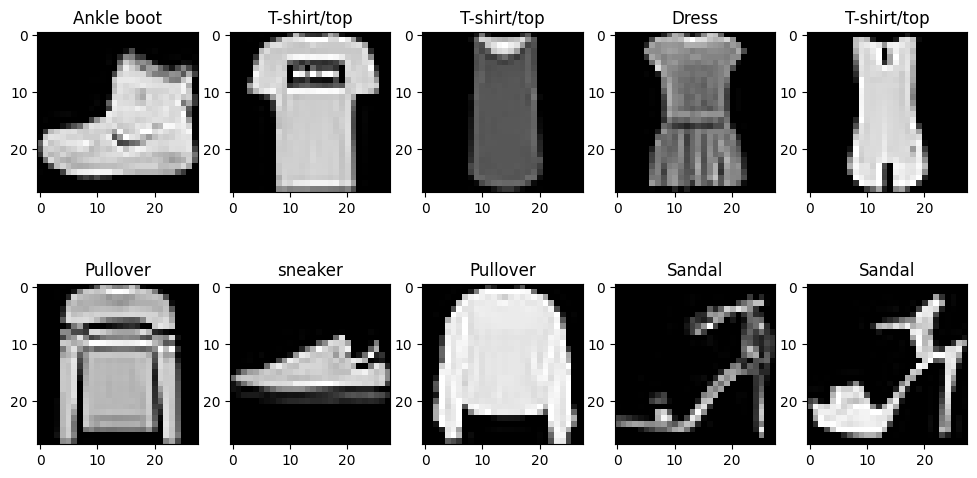

In [84]:
plt.figure(figsize=(12,6)) #height=12 ,width=6
for i in range(10):        #i=0 to 9 --->Every loop displays a image
   plt.subplot(2,5,i+1)    #Divides the figure into a grid of 2 rows and 5 cols
                           #i+1-->position of the current image
   plt.imshow(images[i],cmap='gray') #images[i]-->displays ith image from the images array
   plt.title(label_names[i]) #adds title to each image
plt.show()

In [85]:
#we get 10 images--->
#subplot(2,5) ---->10 images ---->2 rows,5 columns


#we are done with pre-processing
#later in deep learning we see more on this--->image pre-processing

#here we are seeing image-level dimensionality Reduction

#pre-processing we did
#-we did normalization
#-we did re-shaping

#The above are the basic pre-processing

#Next is applying Dimensionality Reduction
